In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
df = pd.read_csv("Data/DTWFeatures/dtw_train.csv")

genres = df['label'].unique()
dist_columns = [f'dist_from_{g}' for g in genres]

dist_data = df[dist_columns + ['label']]

dist_data.head()

,dist_from_pop,dist_from_metal,dist_from_disco,dist_from_jazz,dist_from_rock,dist_from_hiphop,dist_from_country,dist_from_reggae,dist_from_blues,dist_from_classical,label
0,0.927317,0.923353,1.395377,1.844812,1.984301,1.121107,1.432291,1.721052,1.207614,2.488378,pop
1,1.002044,0.454351,1.208401,1.955896,2.267967,1.273775,1.386553,1.856140,1.273919,2.927268,metal
2,1.665534,1.304452,0.326358,0.517286,0.603038,1.649644,0.377038,0.567213,0.573136,0.893061,disco
3,1.100572,1.455295,1.899622,2.190702,2.302584,1.192139,1.917179,2.137417,1.653962,2.718641,pop
4,2.337321,2.640684,0.696293,0.311329,0.285269,2.163075,0.586293,0.495613,0.833183,0.326545,jazz


# EDA

<Axes: xlabel='dist_from_rock', ylabel='Count'>

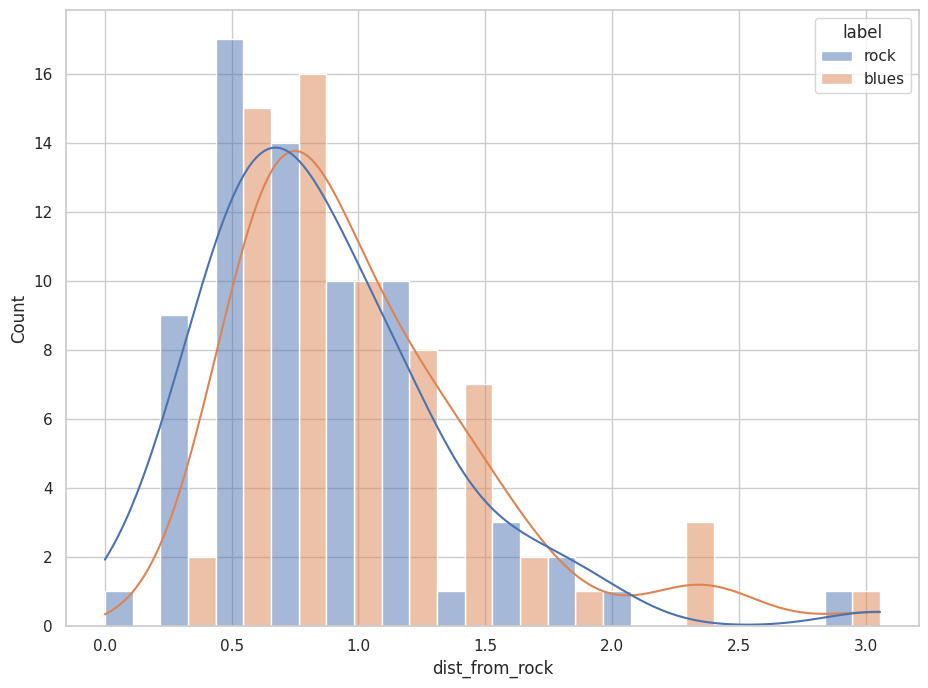

In [28]:
data = dist_data[
    (dist_data['label'] == 'rock') |
    (dist_data['label'] == 'blues')
    ]

plt.figure(figsize=(11, 8))
sns.histplot(data=data, x='dist_from_rock', hue='label', multiple="dodge", kde=True)

In [4]:
X = dist_data.drop('label', axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

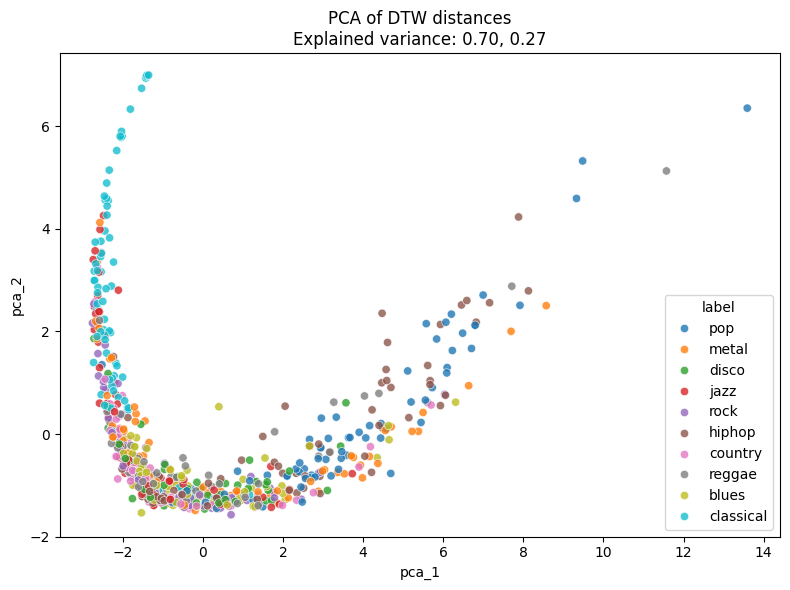

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_data = dist_data.copy()
pca_data["pca_1"] = X_pca[:, 0]
pca_data["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_data,
    x="pca_1",
    y="pca_2",
    hue="label",
    alpha=0.8
)

plt.title(
    f"PCA of DTW distances\n"
    f"Explained variance: "
    f"{pca.explained_variance_ratio_[0]:.2f}, "
    f"{pca.explained_variance_ratio_[1]:.2f}"
)
plt.tight_layout()
plt.show()

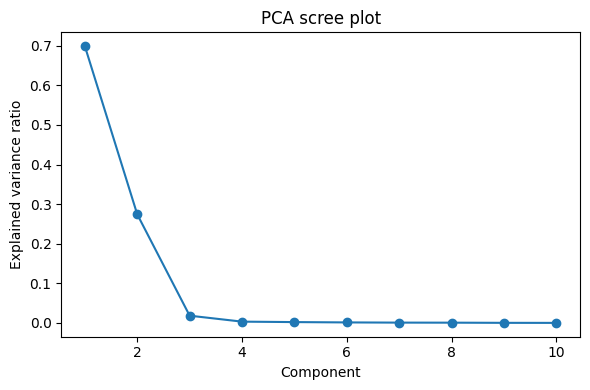

In [6]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.tight_layout()
plt.show()

In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dist_columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [8]:
loadings["PC1"].sort_values(key=np.abs, ascending=False)

dist_from_jazz         0.376071
dist_from_rock         0.374699
dist_from_reggae       0.371154
dist_from_classical    0.366640
dist_from_country      0.349397
dist_from_disco        0.323967
dist_from_blues        0.308443
dist_from_pop         -0.233797
dist_from_hiphop      -0.211287
dist_from_metal       -0.156583
Name: PC1, dtype: float64

In [9]:
loadings["PC2"].sort_values(key=np.abs, ascending=False)

dist_from_metal        0.532591
dist_from_hiphop       0.469650
dist_from_pop          0.468437
dist_from_blues        0.340393
dist_from_disco        0.298618
dist_from_country      0.222880
dist_from_reggae       0.104431
dist_from_classical   -0.094357
dist_from_jazz         0.039129
dist_from_rock        -0.016928
Name: PC2, dtype: float64

# Evaluation

In [24]:
from sklearn.svm import SVC
from model_evaluation import EvalConfig, EvalModel
from sklearn import svm
from sklearn.svm import LinearSVC
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

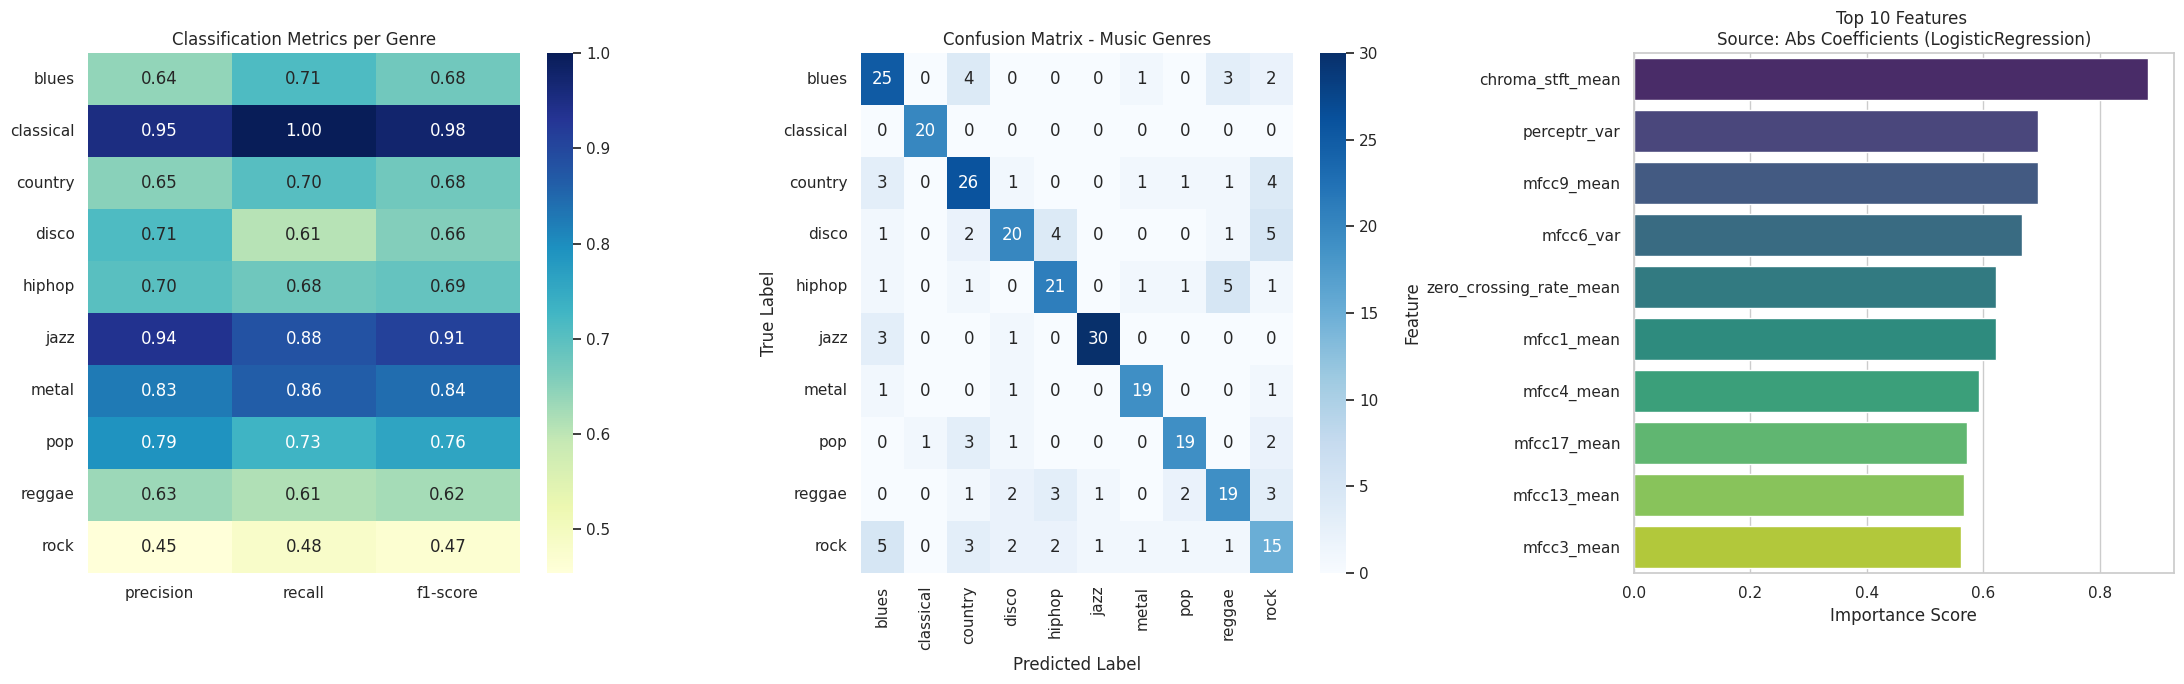

0.7133333333333334


In [25]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('LogReg', LogisticRegression(random_state=42, C=1.0))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/baseline_train.csv",
    test_path="Data/DTWFeatures/baseline_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

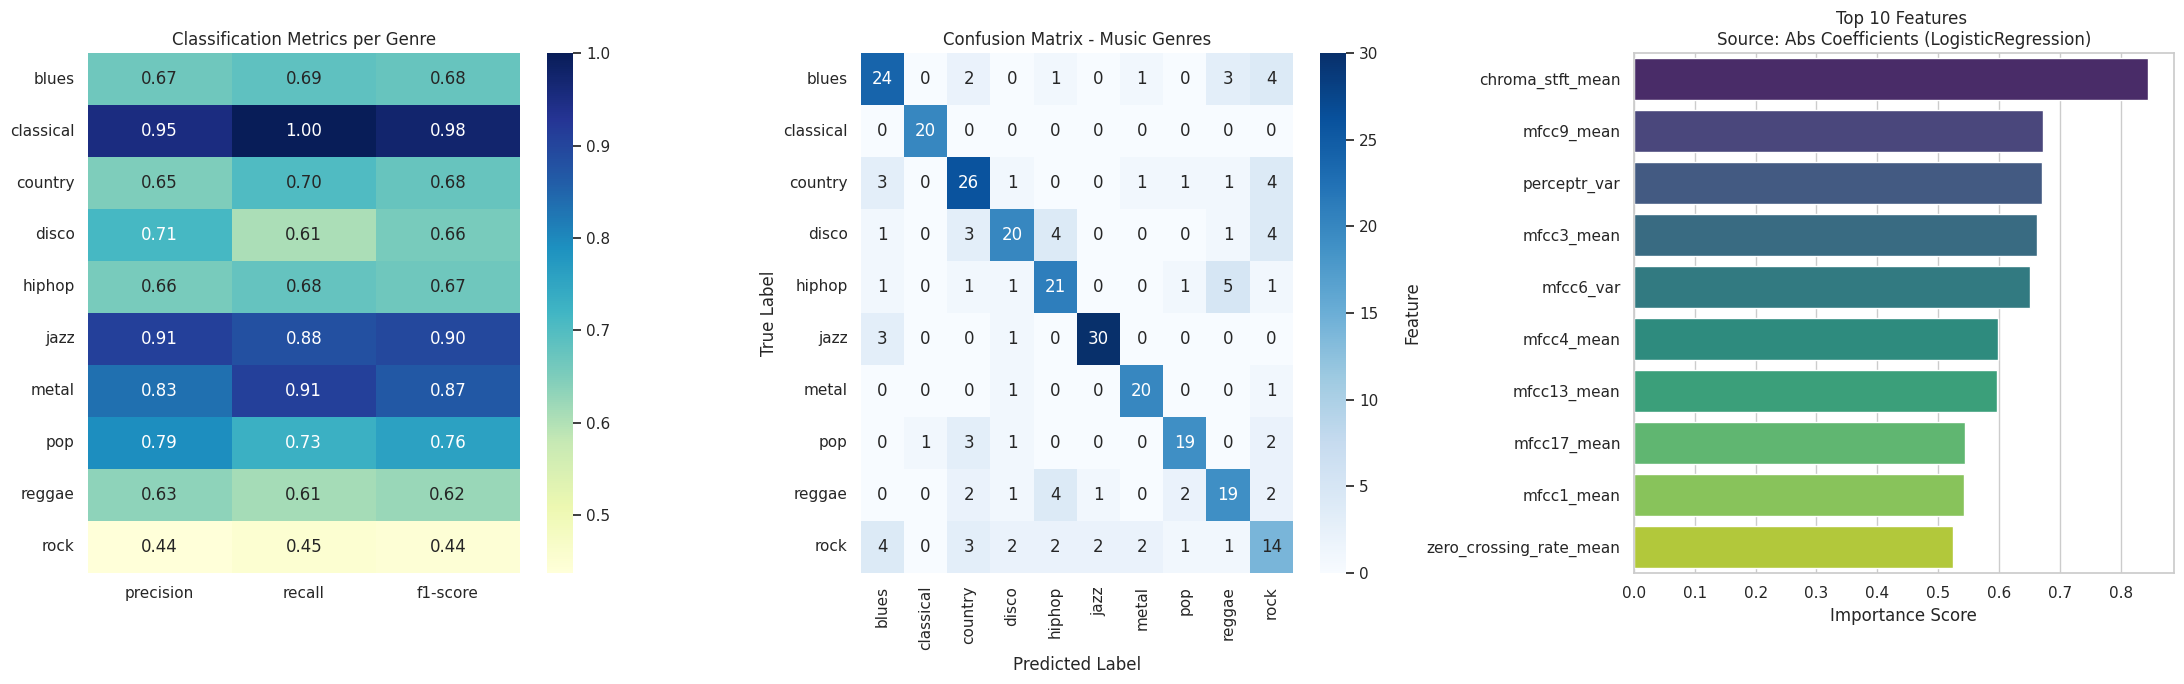

0.71


In [26]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('LogReg', LogisticRegression(random_state=42, C=1.0))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/dtw_train.csv",
    test_path="Data/DTWFeatures/dtw_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

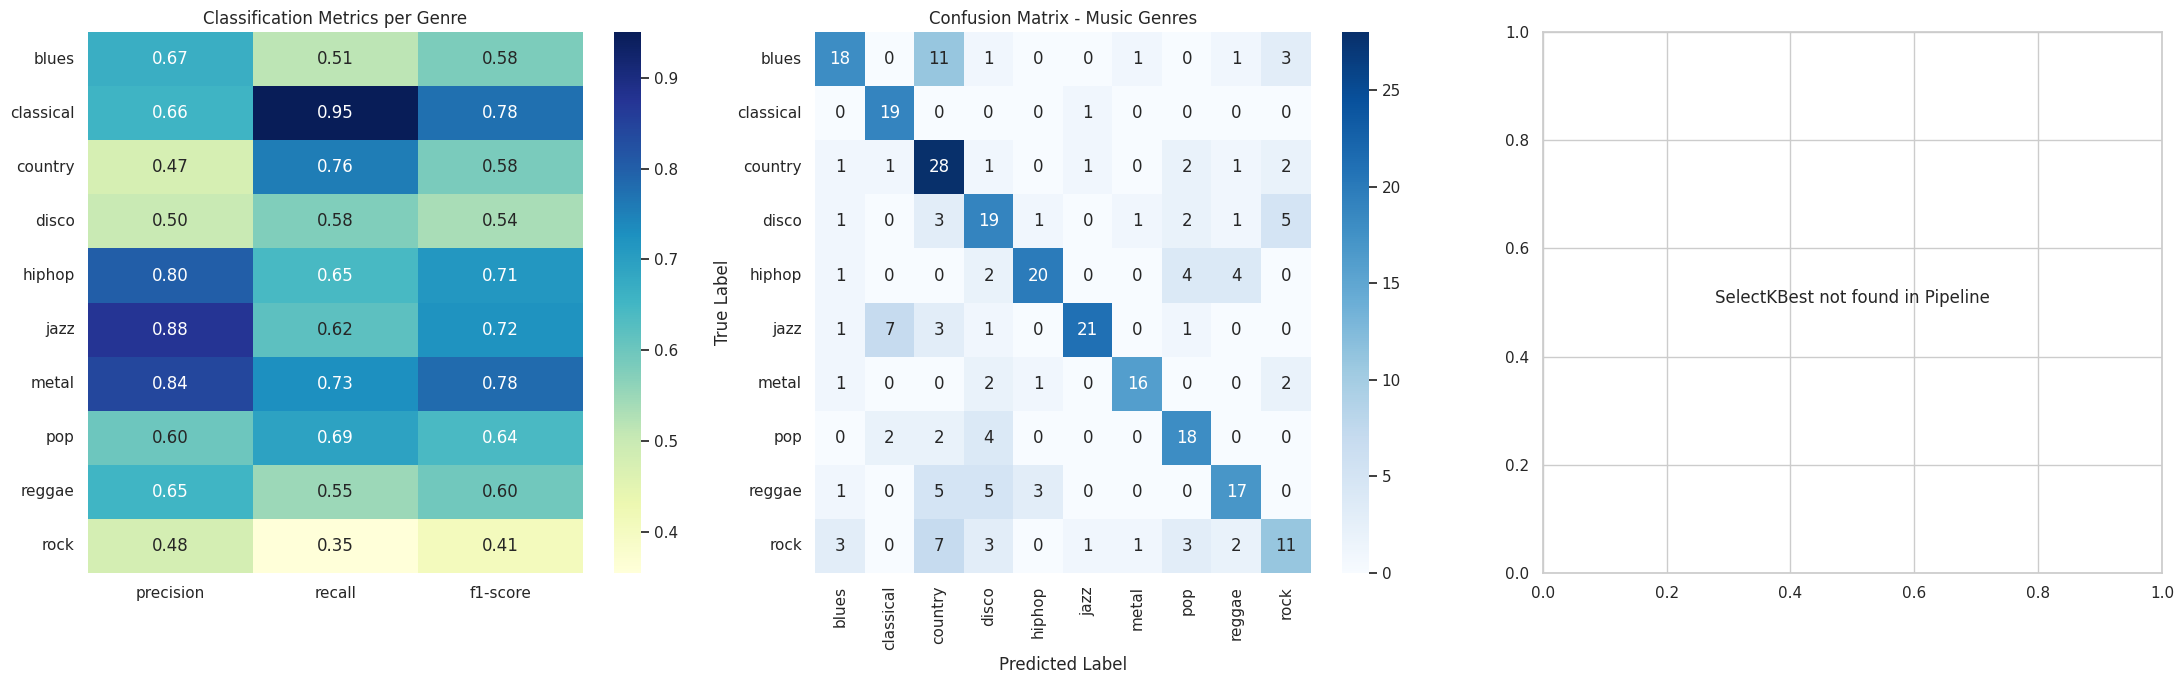

0.6233333333333333


In [31]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=10))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/baseline_train.csv",
    test_path="Data/DTWFeatures/baseline_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

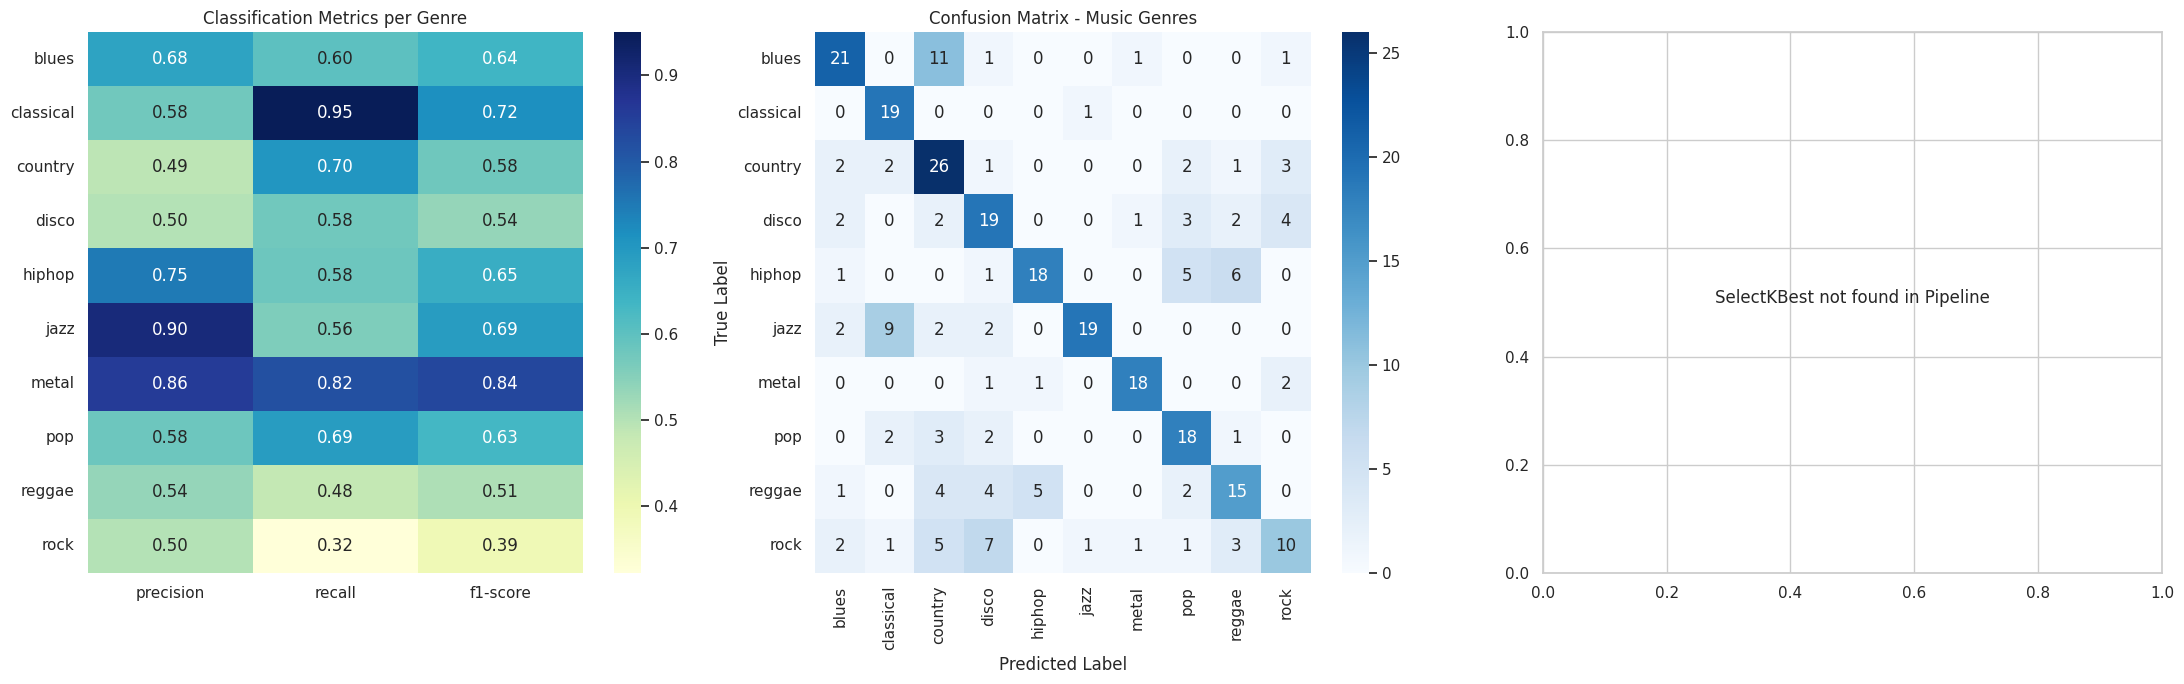

0.61


In [32]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=10))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/dtw_train.csv",
    test_path="Data/DTWFeatures/dtw_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)